# BÀI TOÁN PHÂN LOẠI: DỰ ĐOÁN KHÁCH HÀNG RỜI BỎ NGÂN HÀNG

## Dataset: Bank Customer Churn Dataset

### Mục tiêu bài toán

Bài toán này sử dụng Machine Learning để dự đoán một khách hàng ngân hàng có rời bỏ dịch vụ hay không.

Đây là bài toán **phân loại nhị phân**:

- `Exited = 0`: Khách hàng không rời bỏ ngân hàng
- `Exited = 1`: Khách hàng rời bỏ ngân hàng

### Ý nghĩa thực tế

Trong lĩnh vực ngân hàng, việc dự đoán khách hàng có nguy cơ rời bỏ rất quan trọng. Nếu ngân hàng phát hiện sớm nhóm khách hàng có khả năng rời bỏ, họ có thể đưa ra các chính sách chăm sóc, khuyến mãi hoặc tư vấn phù hợp để giữ chân khách hàng.



In [ ]:
!pip install kaggle ydata-profiling xgboost imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


In [ ]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# RandomOverSampler dùng để xử lý mất cân bằng dữ liệu ở mức oversampling cơ bản
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set(style="whitegrid")

# 1. Thu thập và tải dữ liệu

Có 2 cách để tải dữ liệu:

1. Tải trực tiếp từ Kaggle bằng file `kaggle.json`.
2. Upload file `.csv` thủ công lên Google Colab.

Dataset sử dụng:

**Bank Customer Churn Prediction Dataset**  
Link Kaggle: https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset

In [10]:
from google.colab import drive, files
drive.mount('/content/drive')

# Define the path to your dataset
dataset_path = '/content/drive/MyDrive/ML/BTL/Datasets/Churn_Modelling.csv'
# Load the dataset
df = pd.read_csv(dataset_path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Mô tả các thuộc tính trong dataset

| Cột | Ý nghĩa |
|---|---|
| RowNumber | Số thứ tự dòng |
| CustomerId | Mã khách hàng |
| Surname | Họ của khách hàng |
| CreditScore | Điểm tín dụng |
| Geography | Quốc gia/khu vực của khách hàng |
| Gender | Giới tính |
| Age | Tuổi |
| Tenure | Số năm gắn bó với ngân hàng |
| Balance | Số dư tài khoản |
| NumOfProducts | Số sản phẩm ngân hàng đang sử dụng |
| HasCrCard | Có thẻ tín dụng hay không |
| IsActiveMember | Có phải khách hàng hoạt động thường xuyên không |
| EstimatedSalary | Thu nhập ước tính |
| Exited | Biến mục tiêu, cho biết khách hàng có rời bỏ ngân hàng hay không |

Trong bài toán này, cột `Exited` là biến mục tiêu.

# 2. Tổng quan dataset

Ở phần này, ta xem nhanh kích thước dữ liệu, kiểu dữ liệu, thống kê mô tả và vài dòng đầu tiên.

In [11]:
print("Số dòng và số cột:", df.shape)

Số dòng và số cột: (10000, 14)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# 3. Khám phá và phân tích dữ liệu EDA

In [14]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [15]:
duplicate_count = df.duplicated().sum()
print("Số dòng bị trùng lặp:", duplicate_count)



Số dòng bị trùng lặp: 0


In [16]:
df["Exited"].value_counts()


,count
Exited,
0,7963
1,2037


In [17]:
df["Exited"].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


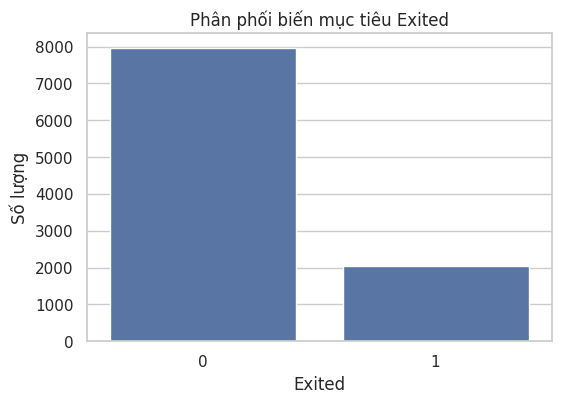

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Exited")
plt.title("Phân phối biến mục tiêu Exited")
plt.xlabel("Exited")
plt.ylabel("Số lượng")
plt.show()

## Nhận xét về biến mục tiêu

Biến `Exited` cho biết khách hàng có rời bỏ ngân hàng hay không.

Số lượng khách hàng `Exited = 0` lớn hơn nhiều so với `Exited = 1`, dữ liệu bị mất cân bằng lớp, không nên chỉ đánh giá mô hình bằng Accuracy, vì mô hình có thể dự đoán đa số là khách hàng không rời bỏ nhưng vẫn đạt Accuracy cao.

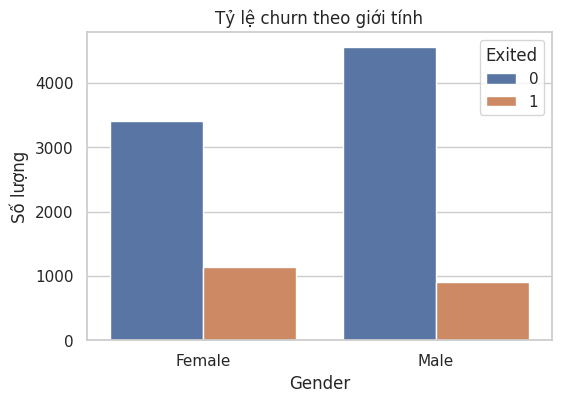

,Exited
Gender,
Female,25.071539
Male,16.455928


In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender", hue="Exited")
plt.title("Tỷ lệ churn theo giới tính")
plt.xlabel("Gender")
plt.ylabel("Số lượng")
plt.show()

gender_churn = df.groupby("Gender")["Exited"].mean().sort_values(ascending=False) * 100
gender_churn

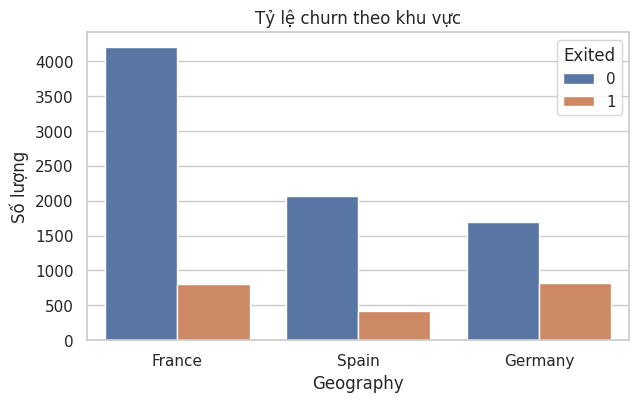

,Exited
Geography,
Germany,32.443204
Spain,16.673395
France,16.154767


In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Geography", hue="Exited")
plt.title("Tỷ lệ churn theo khu vực")
plt.xlabel("Geography")
plt.ylabel("Số lượng")
plt.show()

geo_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False) * 100
geo_churn

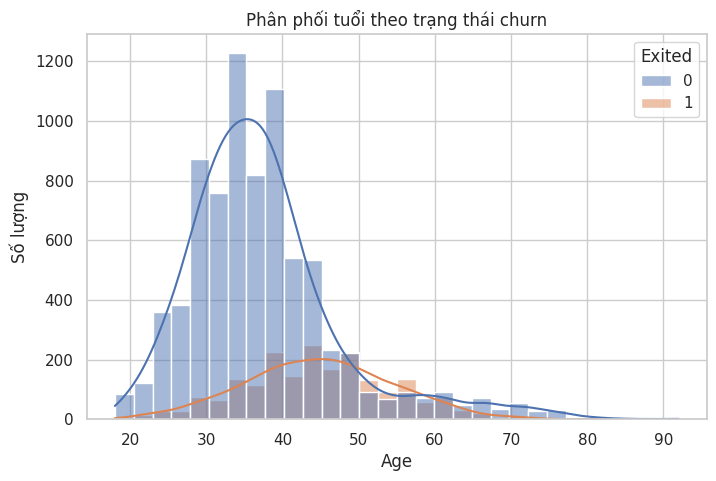

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Exited", kde=True, bins=30)
plt.title("Phân phối tuổi theo trạng thái churn")
plt.xlabel("Age")
plt.ylabel("Số lượng")
plt.show()



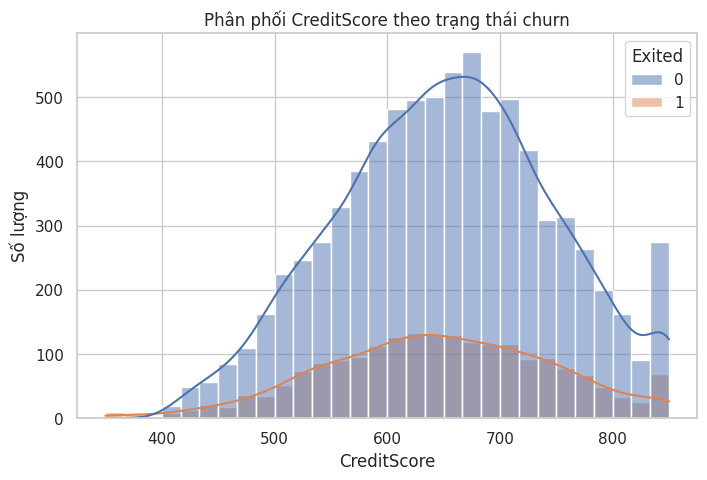

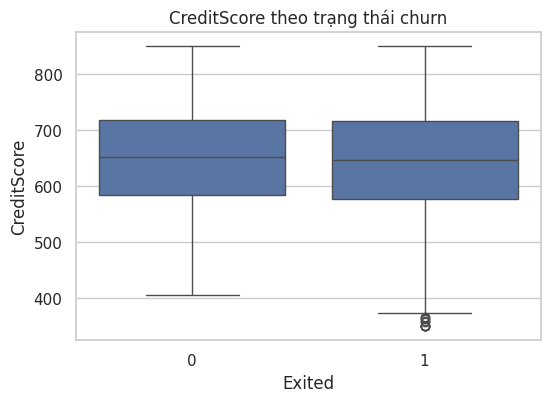

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="CreditScore", hue="Exited", kde=True, bins=30)
plt.title("Phân phối CreditScore theo trạng thái churn")
plt.xlabel("CreditScore")
plt.ylabel("Số lượng")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Exited", y="CreditScore")
plt.title("CreditScore theo trạng thái churn")
plt.xlabel("Exited")
plt.ylabel("CreditScore")
plt.show()

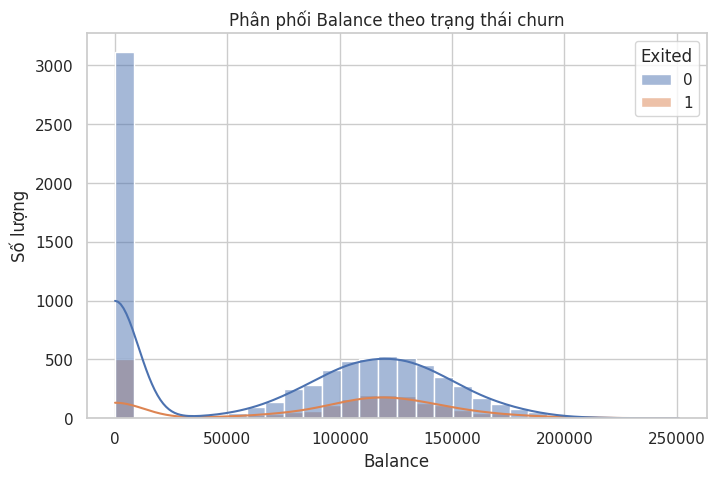

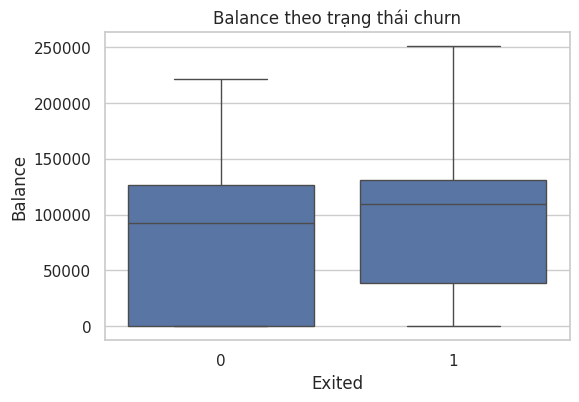

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Balance", hue="Exited", kde=True, bins=30)
plt.title("Phân phối Balance theo trạng thái churn")
plt.xlabel("Balance")
plt.ylabel("Số lượng")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Exited", y="Balance")
plt.title("Balance theo trạng thái churn")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

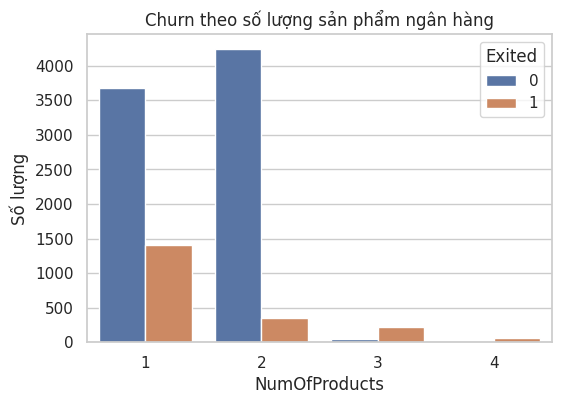

,Exited
NumOfProducts,
4,100.000000
3,82.706767
1,27.714398
2,7.581699


In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="NumOfProducts", hue="Exited")
plt.title("Churn theo số lượng sản phẩm ngân hàng")
plt.xlabel("NumOfProducts")
plt.ylabel("Số lượng")
plt.show()

product_churn = df.groupby("NumOfProducts")["Exited"].mean().sort_values(ascending=False) * 100
product_churn

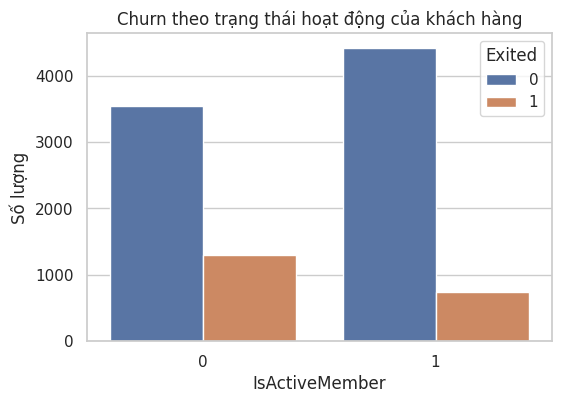

,Exited
IsActiveMember,
0,26.850897
1,14.269074


In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="IsActiveMember", hue="Exited")
plt.title("Churn theo trạng thái hoạt động của khách hàng")
plt.xlabel("IsActiveMember")
plt.ylabel("Số lượng")
plt.show()

active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100
active_churn

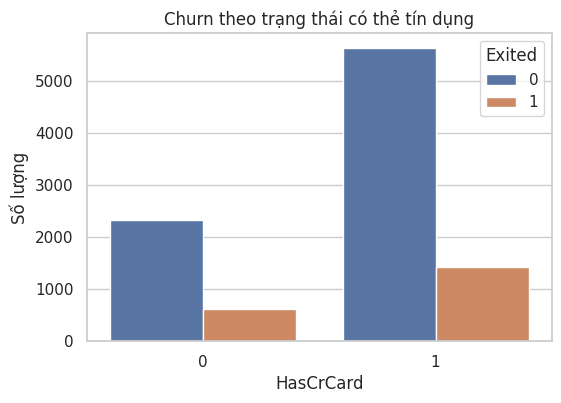

,Exited
HasCrCard,
0,20.814941
1,20.184266


In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HasCrCard", hue="Exited")
plt.title("Churn theo trạng thái có thẻ tín dụng")
plt.xlabel("HasCrCard")
plt.ylabel("Số lượng")
plt.show()

card_churn = df.groupby("HasCrCard")["Exited"].mean() * 100
card_churn

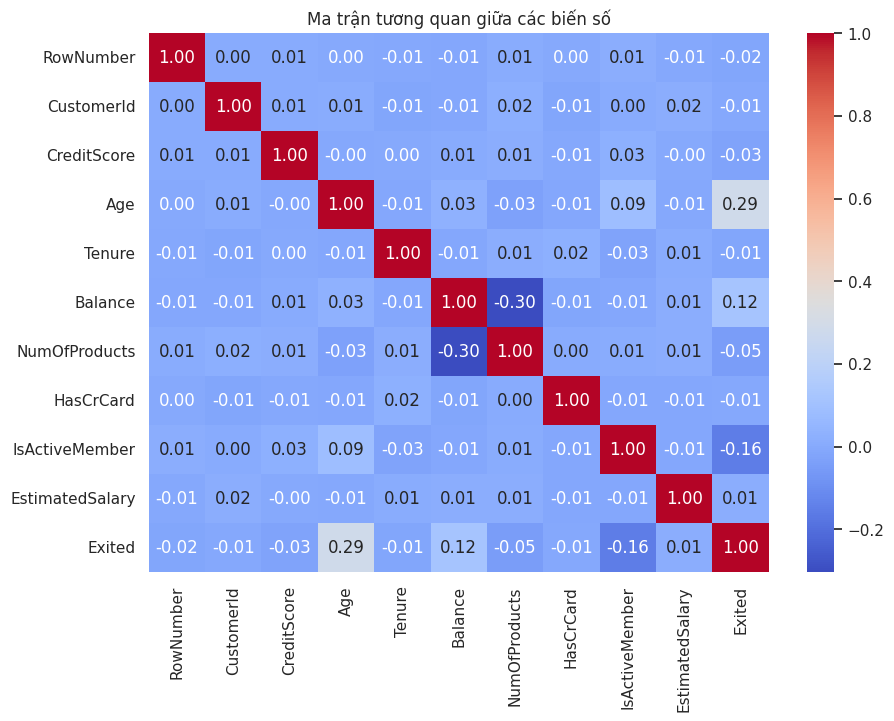

In [27]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

# 4. Báo cáo EDA tự động bằng ydata_profiling

Phần này tạo một file HTML phân tích dữ liệu tự động. File này có thể tải về để nộp kèm hoặc tham khảo khi viết báo cáo.

In [28]:
profile = ProfileReport(
    df.drop(columns=['RowNumber', 'CustomerId', 'Surname']),
    title='Churn Modelling — EDA Report',
    explorative=True,
    minimal=True
)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 121.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Nhận xét sau EDA

Sau khi phân tích dữ liệu, ta có thể rút ra một số nhận xét:

1. Dataset có cả biến số và biến phân loại.
2. Biến mục tiêu `Exited` bị mất cân bằng lớp.
3. Các biến như `Age`, `Balance`, `NumOfProducts`, `IsActiveMember` có thể ảnh hưởng đến khả năng khách hàng rời bỏ.
4. Một số cột như `RowNumber`, `CustomerId`, `Surname` không mang nhiều ý nghĩa dự đoán nên sẽ được loại bỏ trước khi huấn luyện mô hình.

# 5. Tiền xử lý dữ liệu

In [30]:
df_model = df.copy()

drop_cols = ["RowNumber", "CustomerId", "Surname"]

for col in drop_cols:
    if col in df_model.columns:
        df_model = df_model.drop(columns=col)

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (10000, 10)
Kích thước y: (10000,)


In [32]:
categorical_features = ['Geography', 'Gender','HasCrCard','IsActiveMember']
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

print("Biến phân loại:", categorical_features)
print("Biến số:", numeric_features)

Biến phân loại: ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
Biến số: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']


In [33]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 6. Chia dữ liệu train/test

Dữ liệu được chia thành:

- 80% cho tập train
- 20% cho tập test

Tham số `stratify=y` được sử dụng để đảm bảo tỷ lệ giữa hai lớp `Exited = 0` và `Exited = 1` trong tập train và test tương đối giống nhau.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTỷ lệ class trong train:")
print(y_train.value_counts(normalize=True))

print("\nTỷ lệ class trong test:")
print(y_test.value_counts(normalize=True))

Train size: (8000, 10)
Test size: (2000, 10)

Tỷ lệ class trong train:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Tỷ lệ class trong test:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


# 7.1. Xử lý mất cân bằng dữ liệu bằng RandomOverSampler

Trong bài toán Bank Customer Churn, lớp `Exited = 1` thường ít hơn lớp `Exited = 0`. Nếu không xử lý mất cân bằng, mô hình có thể thiên về lớp đa số và bỏ sót nhiều khách hàng thật sự rời bỏ.

Notebook này dùng **RandomOverSampler** để phát triển thêm kỹ thuật oversampling ở mức cơ bản:

```text
preprocessor -> RandomOverSampler -> model
```

Lưu ý:

- RandomOverSampler chỉ nhân bản ngẫu nhiên mẫu của lớp thiểu số.
- Oversampling chỉ được fit trên tập train thông qua `ImbPipeline`.
- Tập test giữ nguyên để đánh giá khách quan.

In [35]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

    return results, y_pred, y_proba

# 8. Tối ưu siêu tham số bằng GridSearchCV

Ta sử dụng `StratifiedKFold` để giữ tỷ lệ lớp trong từng fold. Đồng thời, mỗi mô hình được đặt trong `ImbPipeline`:

```text
preprocessor -> RandomOverSampler -> model
```

Cách này giúp:

- preprocessing chỉ được fit trên dữ liệu train trong từng fold;
- RandomOverSampler chỉ oversampling phần train của từng fold;
- tránh rò rỉ dữ liệu từ validation/test vào quá trình huấn luyện.

Trong GridSearchCV, `scoring="recall"` được ưu tiên vì mục tiêu chính của bài toán churn là giảm số khách hàng rời bỏ bị bỏ sót. Sau đó, ta xem thêm F1-score để cân bằng giữa Precision và Recall.

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [37]:
log_reg_pipe = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

log_reg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=log_reg_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X_train, y_train)

print("Best params Logistic Regression:")
print(log_reg_grid.best_params_)
print("Best CV Recall:", log_reg_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params Logistic Regression:
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'lbfgs'}
Best CV Recall: 0.6901840490797546


In [38]:
dt_pipe = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best params Decision Tree:")
print(dt_grid.best_params_)
print("Best CV Recall:", dt_grid.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best params Decision Tree:
{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best CV Recall: 0.7539877300613497


In [39]:
rf_pipe = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best params Random Forest:")
print(rf_grid.best_params_)
print("Best CV Recall:", rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params Random Forest:
{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Recall: 0.7049079754601226


In [40]:
gb_pipe = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ]
)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best params Gradient Boosting:")
print(gb_grid.best_params_)
print("Best CV Recall:", gb_grid.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params Gradient Boosting:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV Recall: 0.7398773006134969


# 9. Đánh giá các mô hình sau GridSearchCV

In [41]:
tuned_models = {
    "Logistic Regression": log_reg_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

grid_results = []

for name, model in tuned_models.items():
    results, y_pred, y_proba = evaluate_model(name, model, X_test, y_test)
    grid_results.append(results)

grid_results_df = pd.DataFrame(grid_results)

grid_results_sorted = grid_results_df.sort_values(
    by=["Recall", "F1-score"],
    ascending=False
)

grid_results_sorted

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.803,0.510638,0.766585,0.612967,0.865834
1,Decision Tree,0.774,0.466165,0.761671,0.578358,0.847119
0,Logistic Regression,0.716,0.391069,0.710074,0.504363,0.778086
2,Random Forest,0.793,0.493892,0.695332,0.577551,0.852518


In [42]:
final_results_df = grid_results_sorted.copy()
final_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.803,0.510638,0.766585,0.612967,0.865834
1,Decision Tree,0.774,0.466165,0.761671,0.578358,0.847119
0,Logistic Regression,0.716,0.391069,0.710074,0.504363,0.778086
2,Random Forest,0.793,0.493892,0.695332,0.577551,0.852518


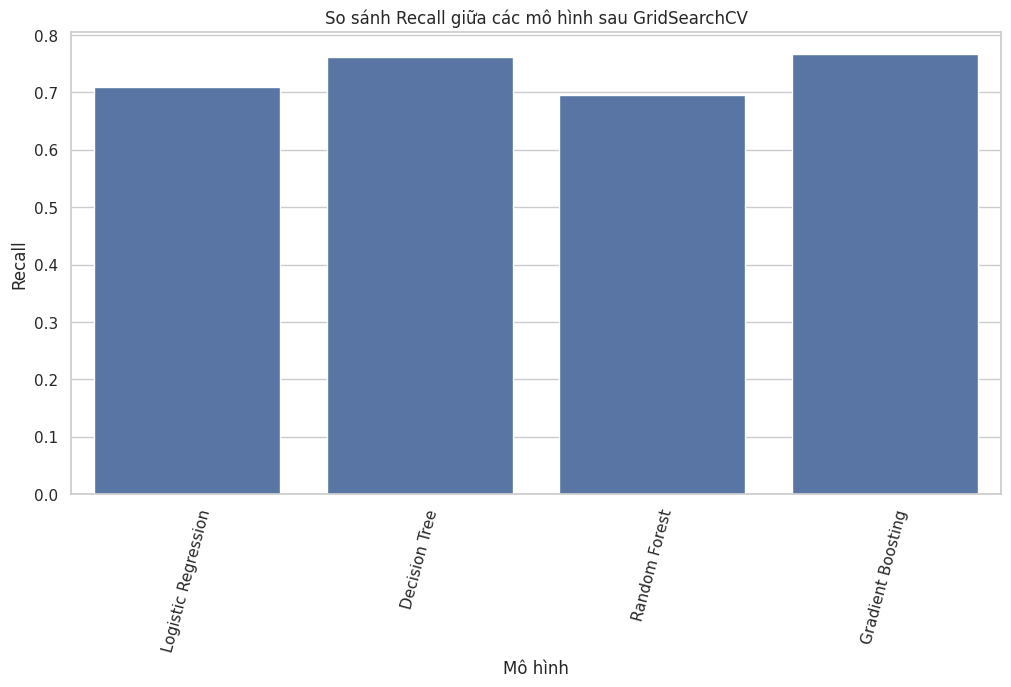

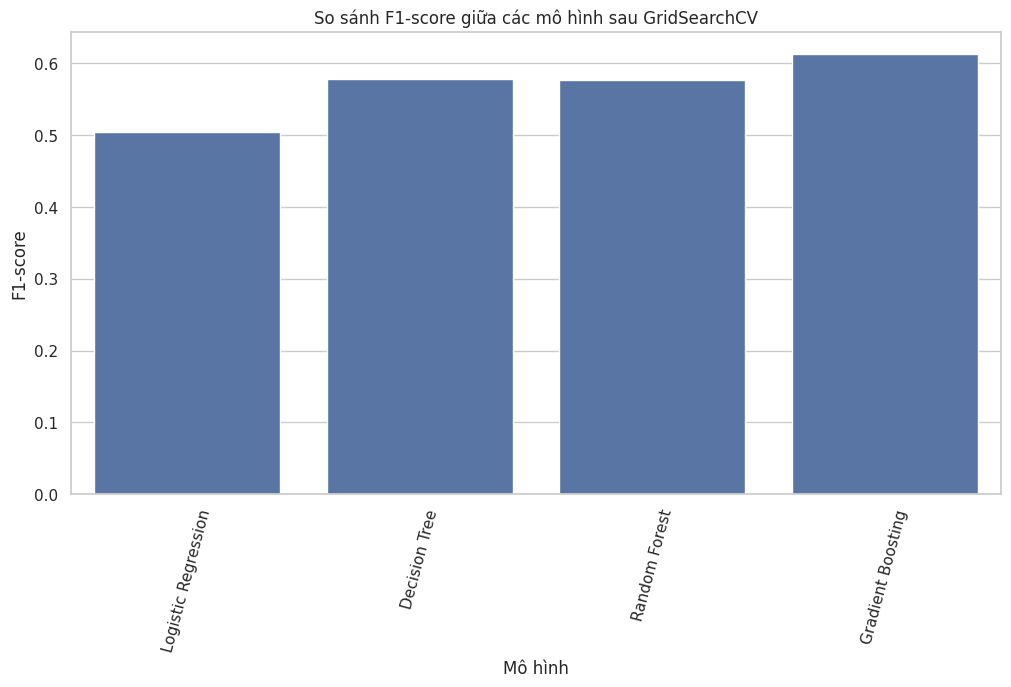

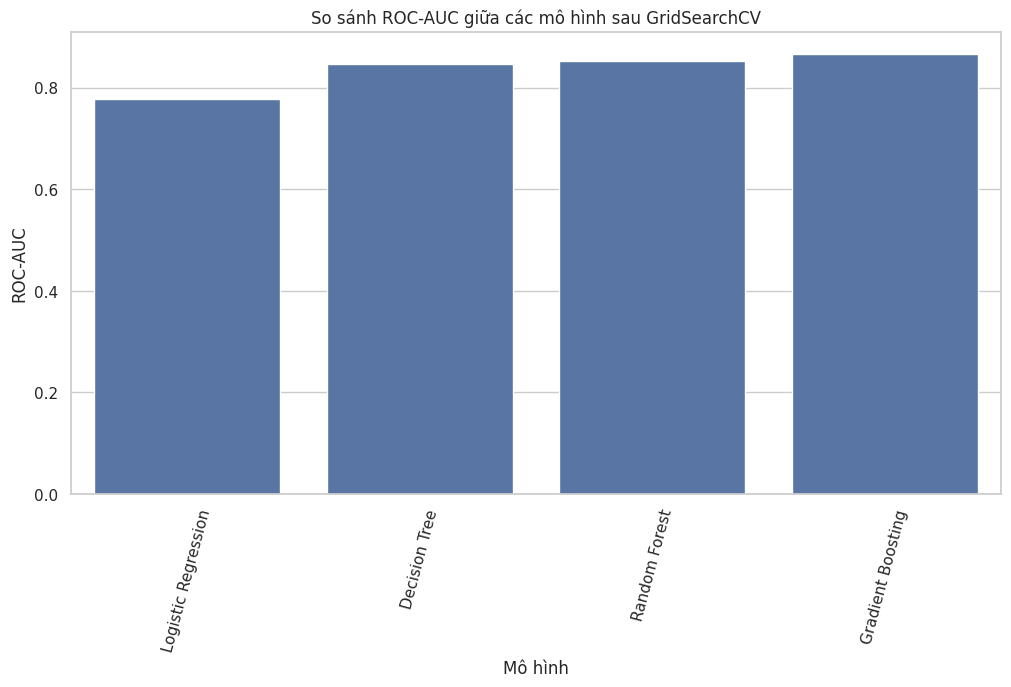

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=grid_results_df, x="Model", y="Recall")
plt.xticks(rotation=75)
plt.title("So sánh Recall giữa các mô hình sau GridSearchCV")
plt.xlabel("Mô hình")
plt.ylabel("Recall")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=grid_results_df, x="Model", y="F1-score")
plt.xticks(rotation=75)
plt.title("So sánh F1-score giữa các mô hình sau GridSearchCV")
plt.xlabel("Mô hình")
plt.ylabel("F1-score")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=grid_results_df, x="Model", y="ROC-AUC")
plt.xticks(rotation=75)
plt.title("So sánh ROC-AUC giữa các mô hình sau GridSearchCV")
plt.xlabel("Mô hình")
plt.ylabel("ROC-AUC")
plt.show()

In [44]:
best_model_name = grid_results_sorted.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Mô hình có Recall tốt nhất:", best_model_name)

Mô hình có Recall tốt nhất: Gradient Boosting


In [45]:
y_pred_final = best_model.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.77      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.82      2000



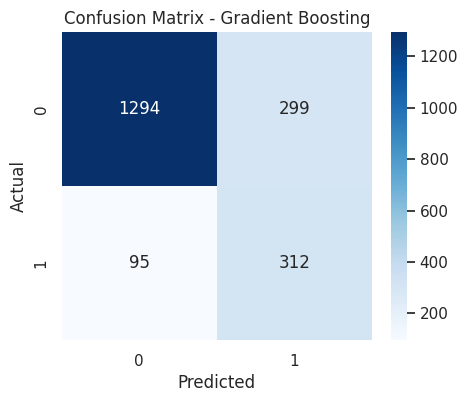

In [46]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 700x500 with 0 Axes>

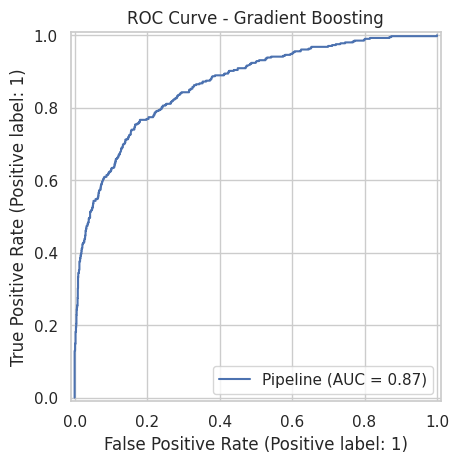

In [47]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

In [48]:
final_results_df.to_csv("gridsearch_model_results.csv", index=False)
files.download("gridsearch_model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# KẾT LUẬN

Trong bài tập này, ta đã xây dựng một hệ thống Machine Learning để dự đoán khách hàng có rời bỏ ngân hàng hay không dựa trên dataset Bank Customer Churn.

## Các bước đã thực hiện

1. Tải và đọc dữ liệu.
2. Khám phá dữ liệu bằng EDA.
3. Kiểm tra missing values và duplicate values.
4. Phân tích phân phối biến mục tiêu `Exited`.
5. Phân tích mối quan hệ giữa churn và các biến như `Age`, `Gender`, `Geography`, `Balance`, `NumOfProducts`, `IsActiveMember`.
6. Tiền xử lý dữ liệu bằng `ColumnTransformer` và `Pipeline`.
7. Mã hóa biến phân loại bằng `OneHotEncoder`.
8. Chuẩn hóa biến số bằng `StandardScaler`.
9. Chia dữ liệu thành tập train và test theo tỷ lệ 80/20.
10. Xử lý mất cân bằng dữ liệu bằng `RandomOverSampler` trong `ImbPipeline`.
11. Bỏ bước baseline và đi thẳng vào `GridSearchCV`.
12. Tối ưu siêu tham số cho nhiều mô hình bằng `GridSearchCV` kết hợp `StratifiedKFold`.
13. Đánh giá mô hình bằng Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix và ROC Curve.
14. Chọn mô hình tốt nhất theo tiêu chí ưu tiên Recall trước, F1-score sau.

## Nhận xét

Bài toán customer churn không nên chỉ đánh giá bằng Accuracy, vì dữ liệu có thể bị mất cân bằng lớp. Trong thực tế, ngân hàng quan tâm nhiều đến việc phát hiện đúng khách hàng có nguy cơ rời bỏ. Vì vậy, Recall được ưu tiên để giảm số khách hàng churn bị bỏ sót, còn F1-score được dùng thêm để cân bằng giữa Precision và Recall.

Trong notebook này, `RandomOverSampler` được sử dụng để nhân bản ngẫu nhiên các mẫu thuộc lớp thiểu số trong tập train. Kỹ thuật này đơn giản hơn SMOTE/SMOTENC nhưng vẫn giúp mô hình học tốt hơn từ lớp khách hàng rời bỏ.

## Mô hình tốt nhất

Mô hình tốt nhất được lựa chọn từ kết quả GridSearchCV, không so sánh với baseline. Cách chọn là ưu tiên **Recall trước, F1-score sau**.

## Hạn chế

Một số hạn chế của bài làm:

- Dataset có kích thước vừa phải, chưa phản ánh toàn bộ dữ liệu thực tế của ngân hàng.
- RandomOverSampler có thể làm tăng nguy cơ overfitting vì nó nhân bản lại mẫu cũ của lớp thiểu số.
- Mô hình vẫn dùng ngưỡng dự đoán mặc định 0.5, chưa tối ưu threshold.
- Không có phần so sánh trước và sau GridSearchCV vì notebook đã được thiết kế để đi thẳng vào GridSearchCV.

## Hướng phát triển

Có thể cải thiện bài toán bằng cách:

- So sánh thêm giữa không oversampling, RandomOverSampler, SMOTE và class_weight.
- Tối ưu threshold thay vì dùng ngưỡng mặc định 0.5.
- Thử thêm các mô hình nâng cao như LightGBM, CatBoost.
- Triển khai mô hình thành một ứng dụng dự đoán churn đơn giản.